In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# Cargar dataset
df = pd.read_csv('../data/raw/educacionCol.csv', sep=',', quotechar='"', encoding='utf-8')
df.head()

C:\Users\isaaa\AppData\Local\Temp\ipykernel_4816\586479386.py:9: DtypeWarning: Columns (15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/educacionCol.csv', sep=',', quotechar='"', encoding='utf-8')


,Código de la Institución,IES PADRE,Institución de Educación Superior (IES),Principal oSeccional,Id_Sector,Id_Caracter,Código del departamento(IES),Departamento de domicilio de la IES,Código del Municipio(IES),Municipio dedomicilio de la IES,...,Id_Nucleo,Núcleo Básico del Conocimiento (NBC),Código del Departamento(Programa),Departamento de oferta del programa,Código del Municipio(Programa),Municipio de oferta del programa,Id Género,Año,Semestre,Total Matriculados
0,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23670,SAN ANDRES DE SOTAVENTO,2,2015,1,2.0
1,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23670,SAN ANDRES DE SOTAVENTO,1,2015,1,2.0
2,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23672,SAN ANTERO,2,2015,1,9.0
3,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23672,SAN ANTERO,1,2015,1,1.0
4,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23675,SAN BERNARDO DEL VIENTO,2,2015,1,18.0


In [ ]:
print("--- VALIDACIÓN DE TIPOS DE DATOS ---")
df.info()

--- VALIDACIÓN DE TIPOS DE DATOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390903 entries, 0 to 390902
Data columns (total 26 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   Código de la Institución                 390903 non-null  int64  
 1   IES PADRE                                390903 non-null  int64  
 2   Institución de Educación Superior (IES)  390903 non-null  object 
 3   Principal oSeccional                     390903 non-null  object 
 4   Id_Sector                                390903 non-null  int64  
 5   Id_Caracter                              390903 non-null  int64  
 6   Código del departamento(IES)             390903 non-null  int64  
 7   Departamento de domicilio de la IES      390903 non-null  object 
 8   Código del Municipio(IES)                390903 non-null  int64  
 9   Municipio dedomicilio de la IES          390903 non-null  object 


In [9]:
print("--- ANÁLISIS DE VALORES NULOS ---")
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100

null_summary = pd.DataFrame({
    'Total Nulos': null_counts,
    'Porcentaje (%)': null_percentages
})

# Mostrar solo las columnas que tienen nulos
print(null_summary[null_summary['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False))

--- ANÁLISIS DE VALORES NULOS ---
Empty DataFrame
Columns: [Total Nulos, Porcentaje (%)]
Index: []


--- DETECCIÓN DE DUPLICADOS ---
Se encontraron 104749 filas exactamente duplicadas en el dataset.


,Código de la Institución,IES PADRE,Institución de Educación Superior (IES),Principal oSeccional,Id_Sector,Id_Caracter,Código del departamento(IES),Departamento de domicilio de la IES,Código del Municipio(IES),Municipio dedomicilio de la IES,...,Id_Nucleo,Núcleo Básico del Conocimiento (NBC),Código del Departamento(Programa),Departamento de oferta del programa,Código del Municipio(Programa),Municipio de oferta del programa,Id Género,Año,Semestre,Total Matriculados
29726,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C,11001,SANTAFE DE BOGOTA,...,13,Medicina veterinaria,11,BOGOTA D.C,11001,SANTAFE DE BOGOTA,2,2016,1,306.0
29725,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C,11001,SANTAFE DE BOGOTA,...,13,Medicina veterinaria,11,BOGOTA D.C,11001,SANTAFE DE BOGOTA,1,2016,1,268.0
225109,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C,11001,SANTAFE DE BOGOTA,...,13,Medicina veterinaria,11,BOGOTA D.C,11001,SANTAFE DE BOGOTA,2,2016,1,306.0
225108,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C,11001,SANTAFE DE BOGOTA,...,13,Medicina veterinaria,11,BOGOTA D.C,11001,SANTAFE DE BOGOTA,1,2016,1,268.0


--- DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS) ---


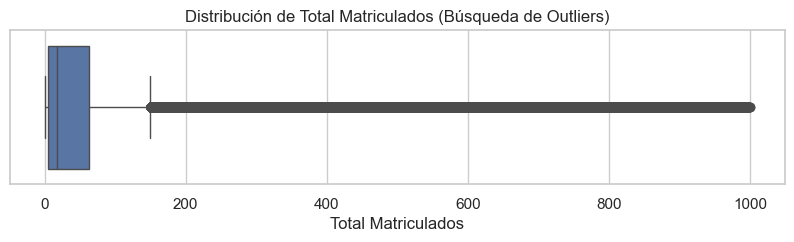

Programas con matrículas atípicamente altas (>150.0): 48142


In [11]:
print("--- DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS) ---")
# Usaremos el Total de Matriculados como métrica principal para buscar outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Total Matriculados'])
plt.title('Distribución de Total Matriculados (Búsqueda de Outliers)')
plt.show()

# Método IQR para cuantificar outliers
Q1 = df['Total Matriculados'].quantile(0.25)
Q3 = df['Total Matriculados'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df[df['Total Matriculados'] > limite_superior]
print(f"Programas con matrículas atípicamente altas (>{limite_superior}): {len(outliers)}")

In [ ]:
print("--- DETECCIÓN DE FORMATO INCONSISTENTE ---")

# Revisar si hay municipios escritos de diferentes formas (Mayúsculas vs Minúsculas o espacios al final)
municipios_unicos = df['Municipio de oferta del programa'].dropna().unique()
print(f"Total municipios únicos (sin limpiar): {len(municipios_unicos)}")

# Aplicando strip y upper para ver si el número se reduce (lo que indicaría inconsistencias de formato)
municipios_limpios = df['Municipio de oferta del programa'].dropna().astype(str).str.strip().str.upper().unique()
print(f"Total municipios únicos (limpiando espacios y mayúsculas): {len(municipios_limpios)}")

# Verificar longitudes raras en los años (deberían ser 4 caracteres)
años_inconsistentes = df[df['Año'].astype(str).str.len() != 4]['Año'].unique()
if len(años_inconsistentes) > 0:
    print(f"Años con formato inconsistente encontrados: {años_inconsistentes}")
else:
    print("La columna 'Año' tiene un formato consistente (4 dígitos).")

--- DETECCIÓN DE FORMATO INCONSISTENTE ---
Total municipios únicos (sin limpiar): 1439
Total municipios únicos (limpiando espacios y mayúsculas): 1004
La columna 'Año' tiene un formato consistente (4 dígitos).
